In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("C:/Users/16692/Downloads/archive (3)/linear_equations_2_variables.csv", encoding='latin-1')

In [4]:
df.head()

,a1,b1,c1,a2,b2,c2,x,y
0,16,37,-75,60,-40,99,-0.231818,2.127273
1,-79,13,31,-27,-3,-19,-0.261905,-3.976190
2,-85,-66,94,54,83,-100,0.344314,0.980808
3,66,-40,-82,-53,-26,70,1.285714,0.071429
4,53,5,-68,-96,-100,-59,1.471992,-2.003112


In [5]:
from sklearn.model_selection import train_test_split 

In [6]:
X=df[['a1','b1','c1','a2','b2','c2']]
y=df[['x','y']]

In [28]:
X_train , X_test , y_train , y_test = train_test_split(X,y,random_state=42,test_size=0.2)
X_val , X_test , y_val , y_test = train_test_split(X , y, test_size=0.5 , random_state=42)

 Model 1 : Linear Regression 

In [64]:


from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Define evaluation function
def evaluate(model, X, y):
    y_predict = model.predict(X)
    mae = mean_absolute_error(y, y_predict)
    rmse = np.sqrt(mean_squared_error(y, y_predict))
    r2 = r2_score(y, y_predict)
    return mae, rmse, r2

# Fit the model
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)

# Evaluate on validation and test sets
mae_val, rmse_val, r2_val = evaluate(reg, X_val_scaled, y_val)
mae_test, rmse_test, r2_test = evaluate(reg, X_test_scaled, y_test)

# Print results
print("Validation Set -> MAE:", mae_val, "RMSE:", rmse_val, "R2:", r2_val)
print("Test Set -> MAE:", mae_test, "RMSE:", rmse_test, "R2:", r2_test)


Validation Set -> MAE: 5.360855995755111 RMSE: 73.92168060860837 R2: 0.00013651207517512143
Test Set -> MAE: 4.978093404275625 RMSE: 63.960077817906416 R2: -0.00014222715471834402


Model 2: Random Forest

In [63]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=10
)

rf_x = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
rf_y = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)

rf_x.fit(X_train, y_train['x'])
rf_y.fit(X_train, y_train['y'])



,n_estimators,300
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [64]:
y_pred_x = rf_x.predict(X_test)
y_pred_y = rf_y.predict(X_test)

# combine into a single matrix for evaluation
y_pred_rf = np.column_stack([y_pred_x, y_pred_y])





In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("Random Forest Test Performance:")
print(" MAE :", mae_rf)
print(" RMSE:", rmse_rf)
print(" R²  :", r2_rf)


Random Forest Test Performance:
 MAE : 5.254787039569728
 RMSE: 59.06284777652019
 R²  : 0.14087446607408388


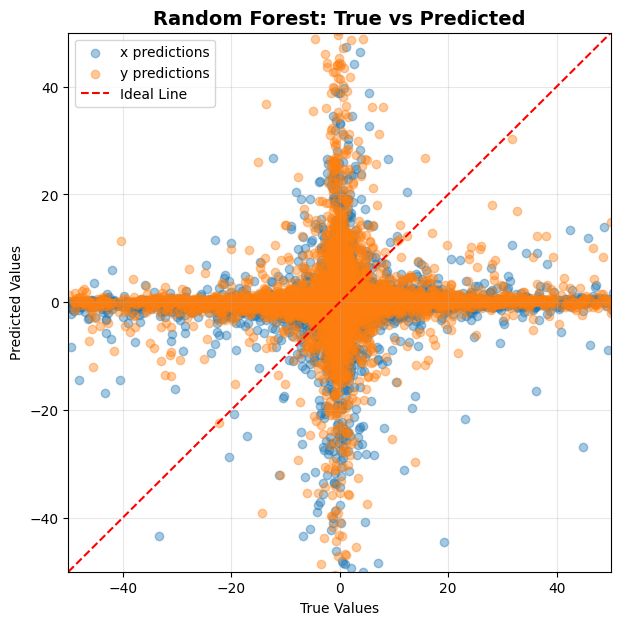

In [66]:
plt.figure(figsize=(7,7))
plt.scatter(y_test['x'], y_pred_rf[:,0], alpha=0.4, label='x predictions')
plt.scatter(y_test['y'], y_pred_rf[:,1], alpha=0.4, label='y predictions')

plt.xlim(-50, 50)
plt.ylim(-50, 50)

plt.plot([-50,50],[-50,50],'r--', label='Ideal Line')
plt.title("Random Forest: True vs Predicted", fontsize=14, weight='bold')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()




Model 3: KNN

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)


In [40]:
mae_knn, rmse_knn, r2_knn = evaluate(knn, X_test, y_test)

print(f"KNN Test Set -> MAE: {mae_knn}, RMSE: {rmse_knn}, R2: {r2_knn}")

KNN Test Set -> MAE: 4.857132272184927, RMSE: 60.73270345186792, R2: 0.09490611969152435


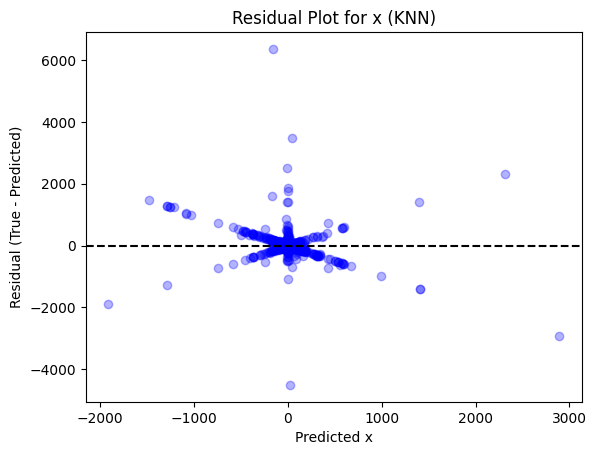

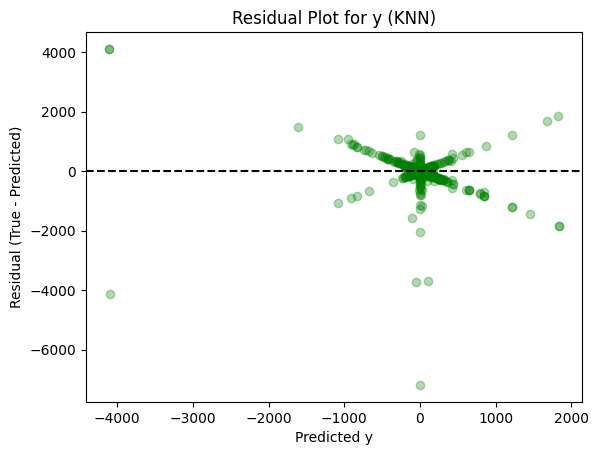

In [41]:
residuals_x = y_test['x'] - y_pred[:,0]
residuals_y = y_test['y'] - y_pred[:,1]

plt.scatter(y_pred[:,0], residuals_x, alpha=0.3, color='blue')
plt.axhline(0, color='black', linestyle='--')
plt.title("Residual Plot for x (KNN)")
plt.xlabel("Predicted x")
plt.ylabel("Residual (True - Predicted)")
plt.show()

plt.scatter(y_pred[:,1], residuals_y, alpha=0.3, color='green')
plt.axhline(0, color='black', linestyle='--')
plt.title("Residual Plot for y (KNN)")
plt.xlabel("Predicted y")
plt.ylabel("Residual (True - Predicted)")
plt.show()





Model 4: Artificial Neural Network 

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf

# Convert pandas DataFrames to numpy arrays
X_train_np = np.array(X_train)
y_train_np = np.array(y_train)
X_val_np = np.array(X_val)
y_val_np = np.array(y_val)



In [78]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_np)
X_val_s   = scaler.transform(X_val_np)


In [79]:
def build_model():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_s.shape[1],)),
        Dense(128, activation='relu'),
        Dense(2)  # predict x and y
    ])
    return model


In [80]:
from tensorflow.keras.callbacks import EarlyStopping

# early stopping callback
es = EarlyStopping(
    monitor='val_loss',
    patience=20,           
    restore_best_weights=True
)

model_adam = build_model()
model_adam.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history_adam = model_adam.fit(
    X_train_s, y_train_np,
    validation_data=(X_val_s, y_val_np),
    epochs=250,           
    batch_size=32,
    callbacks=[es],        
    verbose=0
)



In [58]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping for SGD
es = EarlyStopping(
    monitor='val_loss',
    patience=50,             
    restore_best_weights=True
)

model_sgd = build_model()
model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.0),
    loss='mse',
    metrics=['mae']
)

history_sgd = model_sgd.fit(
    X_train_s, y_train_np,
    validation_data=(X_val_s, y_val_np),
    epochs=400,               # let ES decide when to stop
    batch_size=32,
    callbacks=[es],
    verbose=0
)


In [59]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping for Momentum SGD
es = EarlyStopping(
    monitor='val_loss',
    patience=50,             
    restore_best_weights=True
)

model_momentum = build_model()
model_momentum.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='mse',
    metrics=['mae']
)

history_momentum = model_momentum.fit(
    X_train_s, y_train_np,
    validation_data=(X_val_s, y_val_np),
    epochs=400,                # momentum converges slower → allow more epochs
    batch_size=32,
    callbacks=[es],
    verbose=0
)



In [83]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Make predictions with your trained model
y_train_pred = model_adam.predict(X_train_s, verbose=0)
y_val_pred = model_adam.predict(X_val_s, verbose=0)
y_test_pred = model_adam.predict(X_test, verbose=0)

# Evaluation function
def evaluate_model(y_true, y_pred, dataset_name):
    """
    Calculate MAE, RMSE, and R² for multi-output predictions
    """
    # Overall metrics (averaging across both outputs)
    mae_overall = mean_absolute_error(y_true, y_pred)
    rmse_overall = np.sqrt(mean_squared_error(y_true, y_pred))
    r2_overall = r2_score(y_true, y_pred)
    
    print(f"\n{dataset_name} Set - Overall:")
    print(f"  MAE:  {mae_overall:.4f}")
    print(f"  RMSE: {rmse_overall:.4f}")
    print(f"  R²:   {r2_overall:.4f}")
    
    # Per-output metrics (for x and y separately)
    print(f"\n{dataset_name} Set - Per Output:")
    for i, output_name in enumerate(['x', 'y']):
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        
        print(f"  Output {output_name}:")
        print(f"    MAE:  {mae:.4f}")
        print(f"    RMSE: {rmse:.4f}")
        print(f"    R²:   {r2:.4f}")
    
    return mae_overall, rmse_overall, r2_overall

# Evaluate on all sets
print("="*60)
print("MODEL EVALUATION")
print("="*60)

mae_train, rmse_train, r2_train = evaluate_model(y_train_np, y_train_pred, "Training")
mae_val, rmse_val, r2_val = evaluate_model(y_val_np, y_val_pred, "Validation")
mae_test, rmse_test, r2_test = evaluate_model(y_test_np, y_test_pred, "Test")

print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"{'Dataset':<15} {'MAE':<12} {'RMSE':<12} {'R²':<12}")
print("-"*60)
print(f"{'Training':<15} {mae_train:<12.4f} {rmse_train:<12.4f} {r2_train:<12.4f}")
print(f"{'Validation':<15} {mae_val:<12.4f} {rmse_val:<12.4f} {r2_val:<12.4f}")
print(f"{'Test':<15} {mae_test:<12.4f} {rmse_test:<12.4f} {r2_test:<12.4f}")
print("="*60)


MODEL EVALUATION

Training Set - Overall:
  MAE:  7.4322
  RMSE: 46.4007
  R²:   0.5401

Training Set - Per Output:
  Output x:
    MAE:  7.5165
    RMSE: 44.7971
    R²:   0.5967
  Output y:
    MAE:  7.3479
    RMSE: 47.9507
    R²:   0.4835

Validation Set - Overall:
  MAE:  7.5234
  RMSE: 45.1020
  R²:   0.6228

Validation Set - Per Output:
  Output x:
    MAE:  7.6604
    RMSE: 47.4131
    R²:   0.6507
  Output y:
    MAE:  7.3865
    RMSE: 42.6658
    R²:   0.5950

Test Set - Overall:
  MAE:  351.0233
  RMSE: 769.6362
  R²:   -148.6848

Test Set - Per Output:
  Output x:
    MAE:  353.6946
    RMSE: 808.5324
    R²:   -184.2080
  Output y:
    MAE:  348.3520
    RMSE: 728.6666
    R²:   -113.1616

SUMMARY
Dataset         MAE          RMSE         R²          
------------------------------------------------------------
Training        7.4322       46.4007      0.5401      
Validation      7.5234       45.1020      0.6228      
Test            351.0233     769.6362     -148.6848  

NameError: name 'history_sgd' is not defined

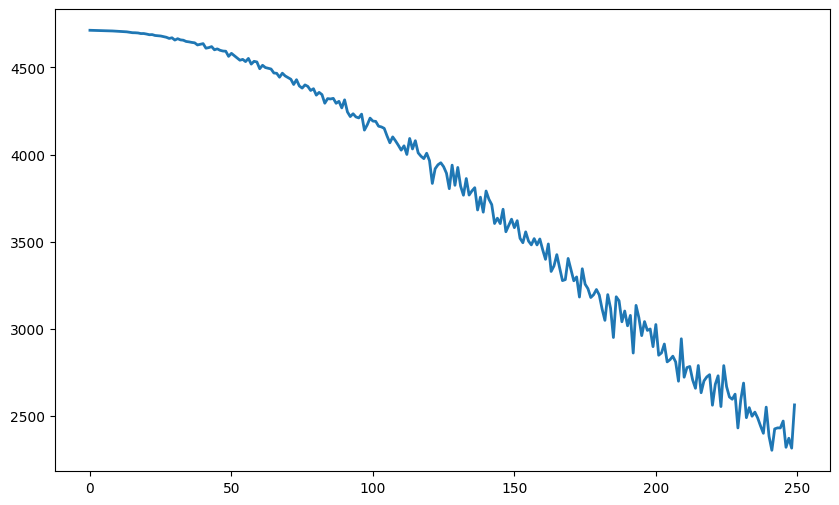

In [84]:
plt.figure(figsize=(10,6))

# plot based on actual lengths recorded in history objects
plt.plot(history_adam.history['loss'], label='Adam', linewidth=2)
plt.plot(history_sgd.history['loss'], label='SGD (no momentum)', linestyle='--')
plt.plot(history_momentum.history['loss'], label='Momentum (0.9)', linestyle='-.')

plt.title("Optimizer Comparison: Adam vs SGD vs Momentum", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Training Loss (MSE)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.show()


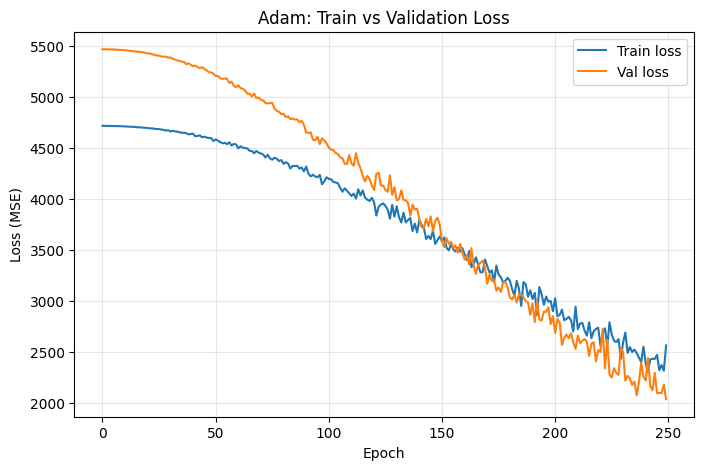

In [85]:
plt.figure(figsize=(8,5))
plt.plot(history_adam.history['loss'], label='Train loss')
plt.plot(history_adam.history['val_loss'], label='Val loss')
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Adam: Train vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


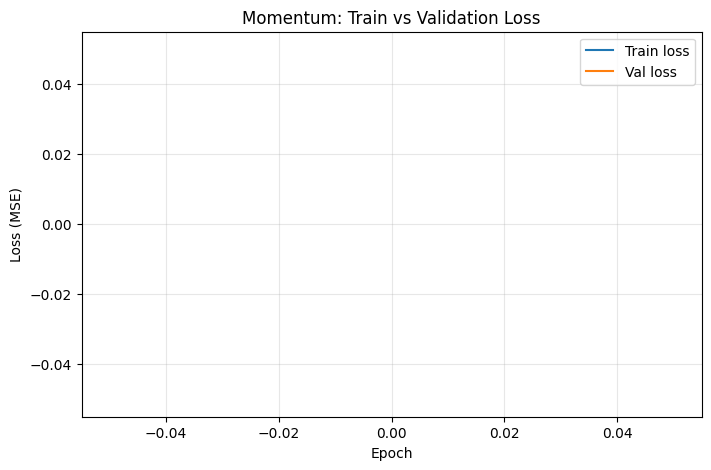

In [61]:
plt.figure(figsize=(8,5))
plt.plot(history_momentum.history['loss'], label='Train loss')
plt.plot(history_momentum.history['val_loss'], label='Val loss')
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Momentum: Train vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

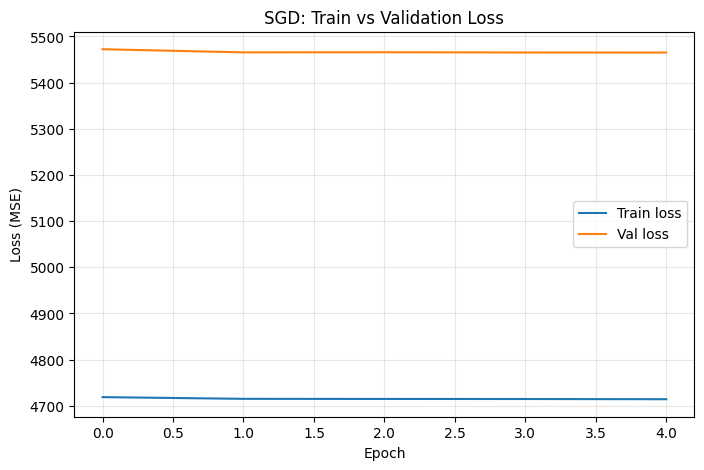

In [62]:
plt.figure(figsize=(8,5))
plt.plot(history_sgd.history['loss'], label='Train loss')
plt.plot(history_sgd.history['val_loss'], label='Val loss')
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("SGD: Train vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Model 5: Support Vector Machine

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVR
import numpy as np

# Scale X
x_scaler = StandardScaler()
X_train_svm = x_scaler.fit_transform(X_train)
X_val_svm   = x_scaler.transform(X_val)
X_test_svm  = x_scaler.transform(X_test)

# Scale y for x-output
y_scaler_x = StandardScaler()
y_train_x_s = y_scaler_x.fit_transform(y_train[['x']])

# Scale y for y-output
y_scaler_y = StandardScaler()
y_train_y_s = y_scaler_y.fit_transform(y_train[['y']])
svr_x = LinearSVR(
    C=40,
    epsilon=0.01,
    random_state=42
)

svr_y = LinearSVR(
    C=40,
    epsilon=0.01,
    random_state=42
)


svr_x.fit(X_train_svm, y_train_x_s.ravel())
svr_y.fit(X_train_svm, y_train_y_s.ravel())



c:\Users\16692\anaconda3\envs\equation-env\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\16692\anaconda3\envs\equation-env\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,epsilon,0.01
,tol,0.0001
,C,40
,loss,'epsilon_insensitive'
,fit_intercept,True
,intercept_scaling,1.0
,dual,'auto'
,verbose,0
,random_state,42
,max_iter,1000


In [17]:
# -------- Predict --------
pred_x_scaled = svr_x.predict(X_val_svm).reshape(-1, 1)
pred_y_scaled = svr_y.predict(X_val_svm).reshape(-1, 1)

# -------- Unscale y --------
pred_x_val = y_scaler_x.inverse_transform(pred_x_scaled)
pred_y_val = y_scaler_y.inverse_transform(pred_y_scaled)

# -------- Combine predictions --------
y_pred_val = np.column_stack([pred_x_val, pred_y_val])

# -------- Evaluate --------
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_val, y_pred_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2 = r2_score(y_val, y_pred_val)

print("LinearSVR Results:")
print(" MAE :", mae)
print(" RMSE:", rmse)
print(" R²  :", r2)




LinearSVR Results:
 MAE : 6.941902936464341
 RMSE: 74.01755029533852
 R²  : -0.0023825694370592787


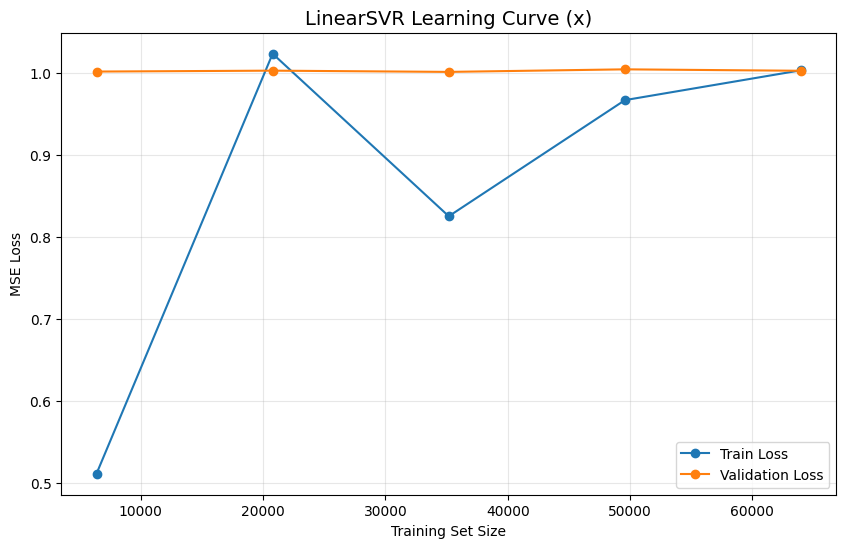

In [23]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curve(model, X, y, title="Learning Curve"):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    train_mean = -np.mean(train_scores, axis=1)
    val_mean = -np.mean(val_scores, axis=1)

    plt.figure(figsize=(10,6))
    plt.plot(train_sizes, train_mean, 'o-', label="Train Loss")
    plt.plot(train_sizes, val_mean, 'o-', label="Validation Loss")
    plt.title(title, fontsize=14)
    plt.xlabel("Training Set Size")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_learning_curve(svr_x, X_train_svm, y_train_x_s.ravel(),
                    "LinearSVR Learning Curve (x)")


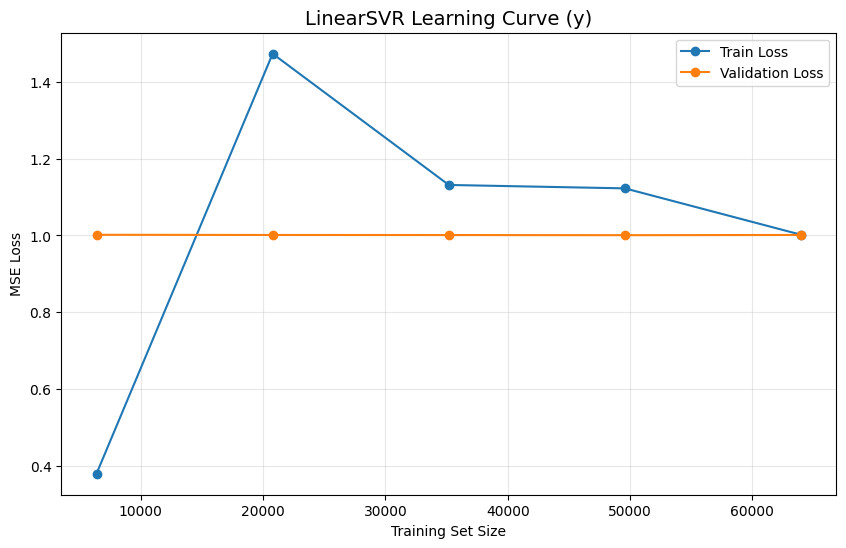

In [24]:
plot_learning_curve(svr_y, X_train_svm, y_train_y_s.ravel(),
                    "LinearSVR Learning Curve (y)")
